# Ethiopia Climate EDA

Week 0 Task 2 notebook for the African Climate Trend Analysis challenge.

This notebook covers:
- data loading and date parsing
- missing-value handling and duplicate removal
- outlier detection
- time series, correlation, and distribution analysis
- cleaned data export

In [91]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import zscore

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [92]:
def resolve_path(*candidates: str) -> Path:
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find any of: {candidates}")


raw_path = resolve_path("data/ethiopia.csv", "../data/ethiopia.csv")
clean_path = raw_path.with_name("ethiopia_clean.csv")
raw_path, clean_path

(PosixPath('../data/ethiopia.csv'), PosixPath('../data/ethiopia_clean.csv'))

## Data Loading And Date Parsing

In [93]:
df = pd.read_csv(raw_path)
df["Country"] = "Ethiopia"
df["date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["date"].dt.month
df = df.sort_values("date").reset_index(drop=True)

print(f"Rows, columns: {df.shape}")
df.head()

Rows, columns: (4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## Replace NASA Sentinel Values

In [94]:
df = df.replace(-999, np.nan)
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


## Duplicates

In [95]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")

Duplicate rows found: 0
Shape after dropping duplicates: (4108, 15)


## Summary Statistics

In [96]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
summary_stats = df[numeric_cols].describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
YEAR,"4,108.00","2,020.13",3.25,"2,015.00","2,017.00","2,020.00","2,023.00","2,026.00"
DOY,"4,108.00",180.12,106.29,1.00,86.00,179.00,272.00,366.00
T2M,"4,108.00",16.07,1.90,10.03,14.82,16.04,17.36,21.53
T2M_MAX,"4,108.00",23.20,2.75,15.65,21.11,22.74,25.17,30.93
T2M_MIN,"4,108.00",10.23,2.61,1.17,8.42,10.99,12.22,15.68
T2M_RANGE,"4,108.00",12.97,3.82,3.56,9.83,13.03,16.02,23.24
PRECTOTCORR,"4,108.00",3.63,6.29,0.00,0.02,0.82,4.58,82.30
RH2M,"4,108.00",68.41,14.74,14.42,59.03,71.12,80.80,91.93
WS2M,"4,108.00",1.98,0.69,0.46,1.41,1.97,2.48,4.13
WS2M_MAX,"4,108.00",3.58,1.12,0.79,2.72,3.53,4.37,7.49


Write a short interpretation here after running the summary table. Focus on the average temperature, precipitation spread, and any unusually wide ranges.

## Missing-Value Report

In [97]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct,
})
missing_report

,missing_count,missing_pct
YEAR,0,0.00
DOY,0,0.00
T2M,0,0.00
T2M_MAX,0,0.00
T2M_MIN,0,0.00
T2M_RANGE,0,0.00
PRECTOTCORR,0,0.00
RH2M,0,0.00
WS2M,0,0.00
WS2M_MAX,0,0.00


In [98]:
missing_over_5 = missing_report[missing_report["missing_pct"] > 5]
missing_over_5

,missing_count,missing_pct


List any columns above 5% missingness here and explain what that may mean for reliability or interpretation.

## Outlier Detection

In [99]:
outlier_cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX",
]

zscore_frame = df[outlier_cols].apply(lambda col: zscore(col, nan_policy="omit"))
outlier_mask = zscore_frame.abs().gt(3).any(axis=1)
outlier_count = int(outlier_mask.sum())

print(f"Rows flagged as outliers: {outlier_count}")
df.loc[outlier_mask, ["date"] + outlier_cols].head()

Rows flagged as outliers: 132


,date,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
144,2015-05-25,18.45,24.94,14.15,29.07,68.37,1.52,3.07
145,2015-05-26,17.60,23.52,13.22,34.38,75.91,1.66,3.53
177,2015-06-27,15.79,19.03,13.33,23.89,83.89,1.81,3.03
214,2015-08-03,15.97,21.06,12.58,23.46,84.73,1.58,2.55
556,2016-07-10,15.20,18.00,12.89,25.19,85.47,1.33,2.99


Document your outlier decision here. In climate data, it is usually better to retain real extreme events unless you find obvious measurement errors.

## Missing-Value Cleaning

In [100]:
weather_fill_cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "T2M_RANGE",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX",
    "PS",
    "QV2M",
]

row_missing_pct = df.isna().mean(axis=1) * 100
rows_over_30 = int((row_missing_pct > 30).sum())
print(f"Rows with more than 30% missing values: {rows_over_30}")

df_clean = df.loc[row_missing_pct <= 30].copy()
df_clean[weather_fill_cols] = df_clean[weather_fill_cols].ffill()

print(f"Cleaned shape: {df_clean.shape}")
df_clean.isna().sum()

Rows with more than 30% missing values: 0
Cleaned shape: (4108, 15)


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
date           0
Month          0
dtype: int64

Document the cleaning choice here: rows above 30% missing were dropped and the remaining weather fields were forward-filled.

## Export Cleaned Data

In [101]:
df_clean.to_csv(clean_path, index=False)
print(f"Saved cleaned data to {clean_path}")

Saved cleaned data to ../data/ethiopia_clean.csv


## Time Series Analysis

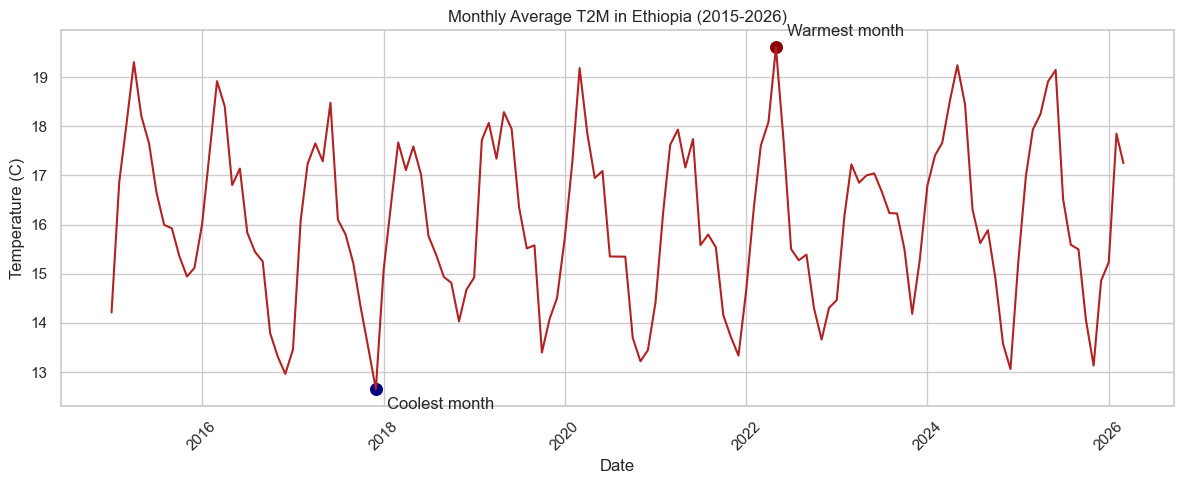

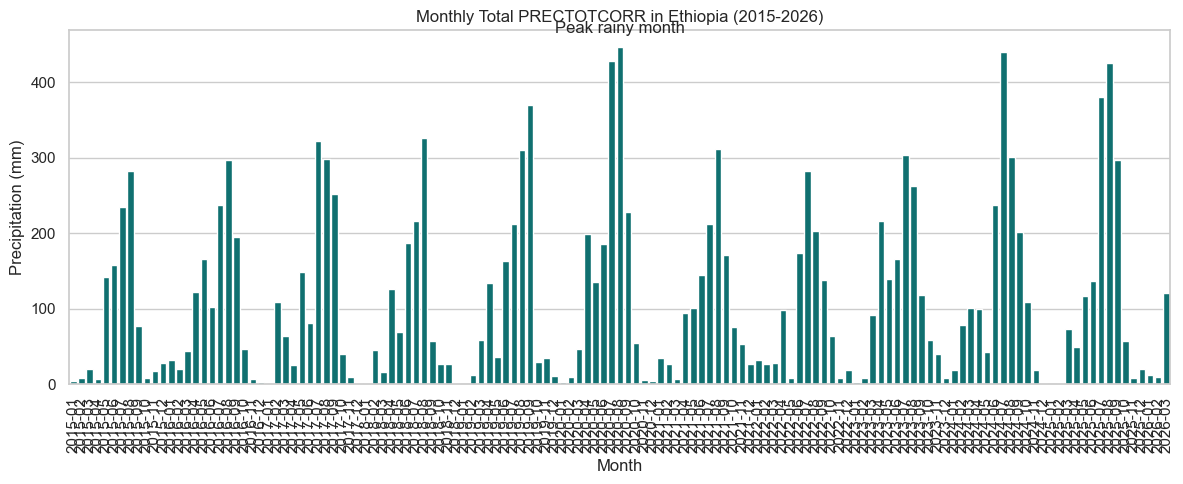

In [102]:
monthly = (
    df_clean.set_index("date")
    .resample("MS")
    .agg({"T2M": "mean", "PRECTOTCORR": "sum"})
    .reset_index()
)

warmest = monthly.loc[monthly["T2M"].idxmax()]
coolest = monthly.loc[monthly["T2M"].idxmin()]
rainiest = monthly.loc[monthly["PRECTOTCORR"].idxmax()]

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=monthly, x="date", y="T2M", ax=ax, color="firebrick")
ax.scatter(warmest["date"], warmest["T2M"], color="darkred", s=70)
ax.scatter(coolest["date"], coolest["T2M"], color="navy", s=70)
ax.annotate("Warmest month", (warmest["date"], warmest["T2M"]), xytext=(8, 8), textcoords="offset points")
ax.annotate("Coolest month", (coolest["date"], coolest["T2M"]), xytext=(8, -14), textcoords="offset points")
ax.set_title("Monthly Average T2M in Ethiopia (2015-2026)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=monthly, x=monthly["date"].dt.strftime("%Y-%m"), y="PRECTOTCORR", ax=ax, color="teal")
peak_index = monthly["PRECTOTCORR"].idxmax()
ax.annotate(
    "Peak rainy month",
    (peak_index, rainiest["PRECTOTCORR"]),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
)
ax.set_title("Monthly Total PRECTOTCORR in Ethiopia (2015-2026)")
ax.set_xlabel("Month")
ax.set_ylabel("Precipitation (mm)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

Comment on visible trends or anomalies here. Mention warming periods, cooler intervals, or unusually wet months.

## Correlation And Relationships

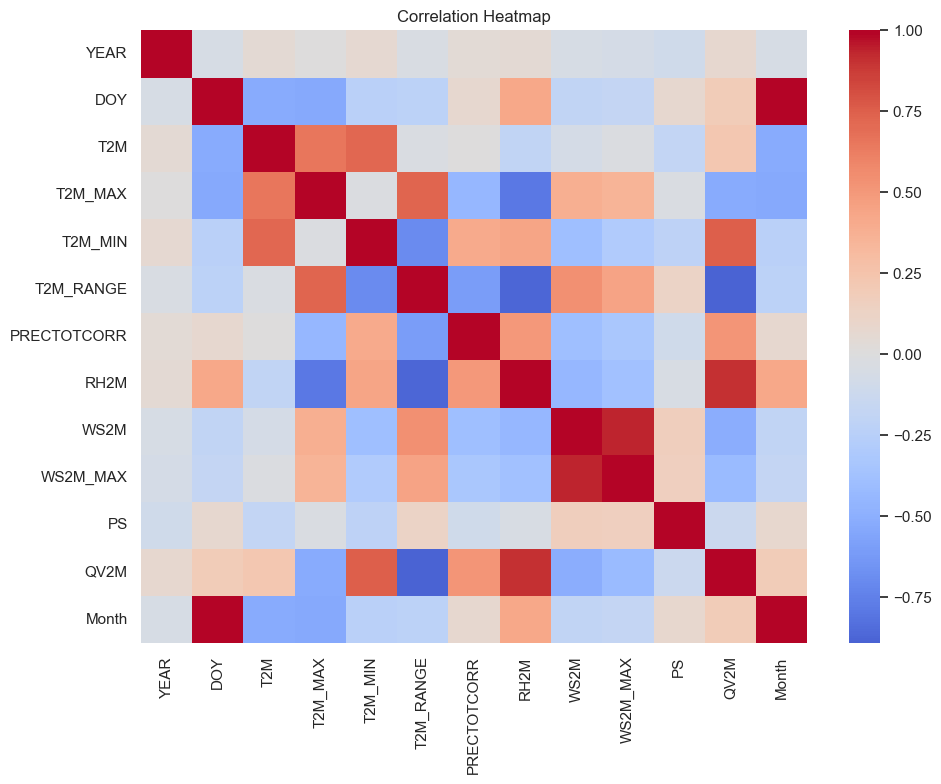

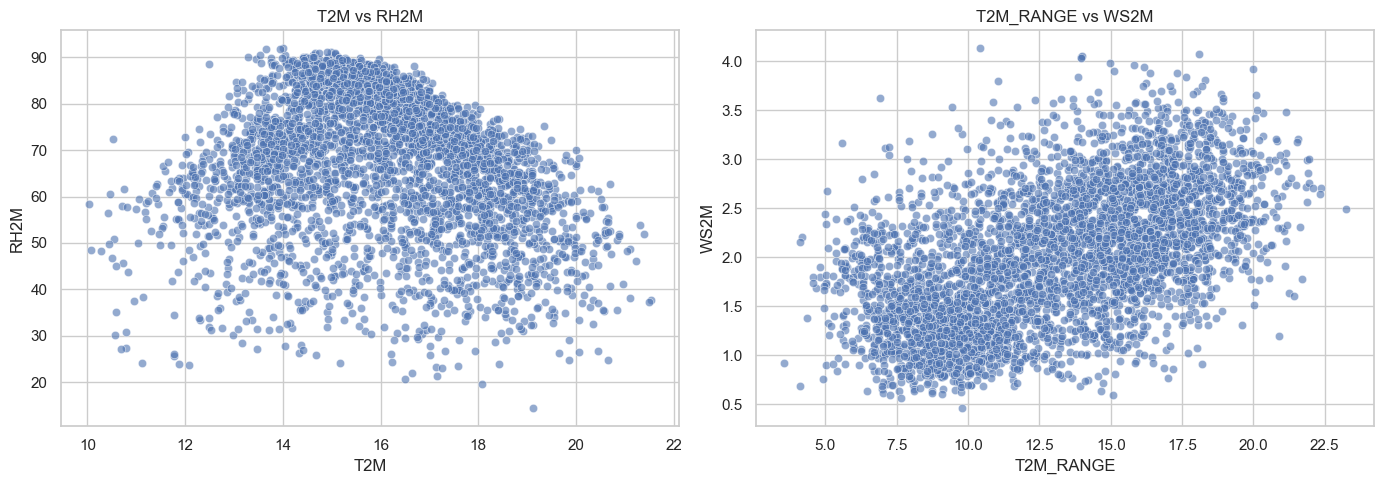

In [103]:
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df_clean, x="T2M", y="RH2M", ax=axes[0], alpha=0.6)
axes[0].set_title("T2M vs RH2M")

sns.scatterplot(data=df_clean, x="T2M_RANGE", y="WS2M", ax=axes[1], alpha=0.6)
axes[1].set_title("T2M_RANGE vs WS2M")
plt.tight_layout()
plt.show()

In [104]:
strongest_corr = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .drop_duplicates()
)
strongest_corr.head(3)

Month     DOY    1.00
WS2M_MAX  WS2M   0.94
RH2M      QV2M   0.90
dtype: float64

Interpret the three strongest correlations here. Explain whether they make physical sense in the context of climate variables.

## Distribution Analysis

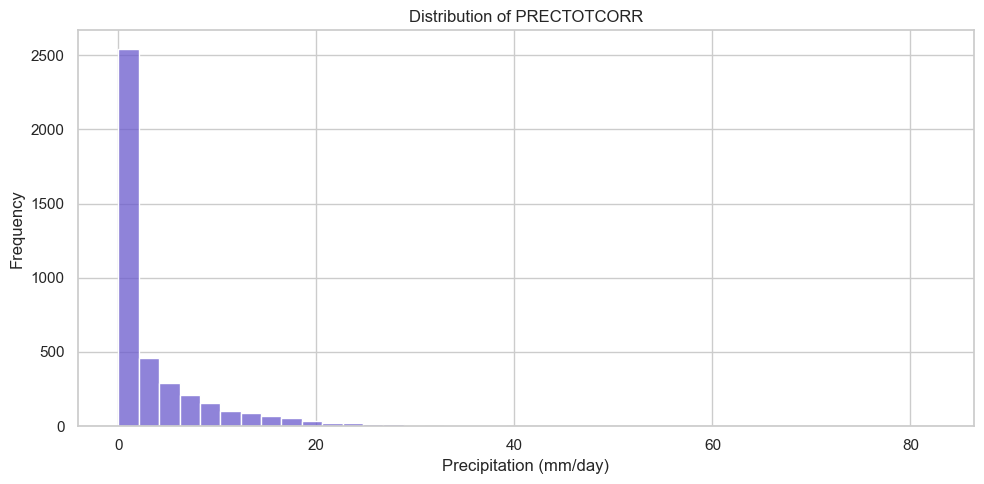

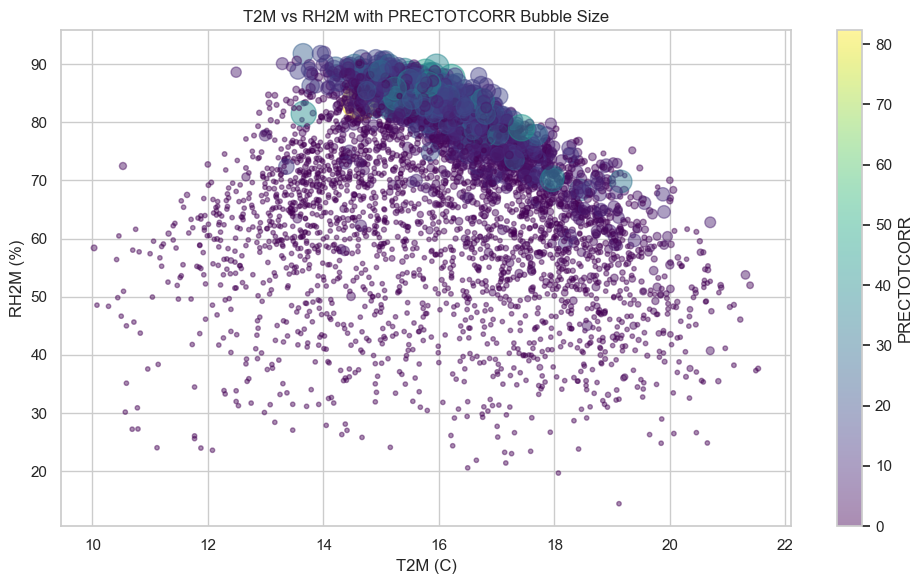

In [105]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_clean["PRECTOTCORR"].dropna(), bins=40, ax=ax, color="slateblue")
ax.set_title("Distribution of PRECTOTCORR")
ax.set_xlabel("Precipitation (mm/day)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
bubble_size = df_clean["PRECTOTCORR"].fillna(0).clip(lower=0) * 8 + 10
scatter = ax.scatter(
    df_clean["T2M"],
    df_clean["RH2M"],
    s=bubble_size,
    c=df_clean["PRECTOTCORR"],
    cmap="viridis",
    alpha=0.45,
)
ax.set_title("T2M vs RH2M with PRECTOTCORR Bubble Size")
ax.set_xlabel("T2M (C)")
ax.set_ylabel("RH2M (%)")
plt.colorbar(scatter, ax=ax, label="PRECTOTCORR")
plt.tight_layout()
plt.show()

Comment on the precipitation distribution here. If the histogram is heavily right-skewed, note that a log-scaled view may be useful.